In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import re
import json
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset as TorchDataset, DataLoader
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    get_linear_schedule_with_warmup,
)
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_recall_fscore_support, confusion_matrix,
)

print("Imports complete")

2026-03-21 09:07:39.921963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774084060.153975      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774084060.215750      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774084060.751164      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774084060.751209      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774084060.751212      23 computation_placer.cc:177] computation placer alr

Imports complete


In [2]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    gpu_name = torch.cuda.get_device_properties(0).name
    print(f"GPU  : {gpu_name}")
    print(f"VRAM : {vram_gb:.1f} GB")
    if vram_gb < 14:
        print("WARNING: VRAM < 14 GB — xem xét giảm batch_size")
    else:
        print("OK: VRAM đủ cho max_seq_length=512")

Device: cuda
GPU  : Tesla P100-PCIE-16GB
VRAM : 15.9 GB
OK: VRAM đủ cho max_seq_length=512


In [3]:
TARGET_MAX_LENGTH = 512  # theo bài báo: max_sequence_length = 512


def expand_position_embeddings(model, new_max_length: int) -> None:
    """
    Mở rộng position embeddings PhoBERT từ 258 → new_max_length+2
    bằng linear interpolation. Cần +2 vì PhoBERT dùng padding_idx=0 và offset=1.
    """
    import torch.nn.functional as F

    pos_emb_layer        = model.embeddings.position_embeddings
    old_weight           = pos_emb_layer.weight.data       # (old_max, hidden)
    old_max, hidden_size = old_weight.shape
    new_max              = new_max_length + 2              # +2 cho padding & offset

    if old_max == new_max:
        print(f"  Position embeddings đã là {old_max}, bỏ qua.")
        return

    print(f"  Interpolating position embeddings: {old_max} → {new_max} ...")
    old_w_t  = old_weight.T.unsqueeze(0)                   # (1, hidden, old_max)
    new_w_t  = F.interpolate(
        old_w_t.float(), size=new_max, mode="linear", align_corners=False
    )                                                       # (1, hidden, new_max)
    new_weight = new_w_t.squeeze(0).T                       # (new_max, hidden)

    new_pos_emb        = nn.Embedding(new_max, hidden_size, padding_idx=0)
    new_pos_emb.weight = nn.Parameter(new_weight.to(old_weight.dtype))
    model.embeddings.position_embeddings = new_pos_emb

    model.embeddings.register_buffer(
        "position_ids",
        torch.arange(new_max).expand((1, -1)),
        persistent=False,
    )
    if hasattr(model.embeddings, "token_type_ids"):
        model.embeddings.register_buffer(
            "token_type_ids",
            torch.zeros(1, new_max, dtype=torch.long),
            persistent=False,
        )
    print(f"  Done. Position embedding shape: {new_pos_emb.weight.shape}")


def save_expanded_model(model_name: str, target_length: int) -> str:
    """Load, expand, lưu ra thư mục tạm. Có flag để không expand lại."""
    save_dir  = f"/kaggle/working/phobert_expanded_{target_length}/{model_name.split('/')[-1]}"
    done_flag = os.path.join(save_dir, "expansion_done.flag")
    os.makedirs(save_dir, exist_ok=True)

    if os.path.exists(done_flag):
        print(f"  Đã mở rộng trước đó, dùng lại: {save_dir}")
        return save_dir

    print(f"\nMở rộng position embeddings: {model_name} → {target_length} tokens ...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    config    = AutoConfig.from_pretrained(model_name)
    model_tmp = AutoModel.from_pretrained(model_name)

    expand_position_embeddings(model_tmp, target_length)
    config.max_position_embeddings = target_length + 2

    model_tmp.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    config.save_pretrained(save_dir)

    with open(done_flag, "w") as f:
        f.write(f"expanded to {target_length}")

    del model_tmp
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  Saved → {save_dir}")
    return save_dir

In [4]:
POSSIBLE_MODELS = ["vinai/phobert-base", "vinai/phobert-large"]
MODELS_TO_TRAIN = {}  # key: tên ngắn, value: đường dẫn model (đã expand)

for candidate_model in POSSIBLE_MODELS:
    try:
        _cfg     = AutoConfig.from_pretrained(candidate_model)
        orig_max = _cfg.max_position_embeddings - 2  # 256 với PhoBERT

        _tok   = AutoTokenizer.from_pretrained(candidate_model, use_fast=False)
        _model = AutoModel.from_pretrained(candidate_model)
        del _model, _tok
        gc.collect()

        name_key = "phobert-base" if "base" in candidate_model else "phobert-large"

        if orig_max < TARGET_MAX_LENGTH:
            print(f"  {name_key}: orig={orig_max} < {TARGET_MAX_LENGTH} → mở rộng ...")
            expanded_path = save_expanded_model(candidate_model, TARGET_MAX_LENGTH)
            MODELS_TO_TRAIN[name_key] = expanded_path
        else:
            MODELS_TO_TRAIN[name_key] = candidate_model
            print(f"  {name_key}: max_position={orig_max} >= {TARGET_MAX_LENGTH}, không cần expand.")

        print(f"  OK  {name_key}: {MODELS_TO_TRAIN[name_key]}")

    except Exception as e:
        print(f"  SKIP {candidate_model}: {e}")
        import traceback; traceback.print_exc()

if not MODELS_TO_TRAIN:
    raise RuntimeError("Không tìm thấy model nào khả dụng!")

first_model            = list(MODELS_TO_TRAIN.values())[0]
_cfg                   = AutoConfig.from_pretrained(first_model)
SAFE_MAX_LENGTH        = _cfg.max_position_embeddings - 2
RECOMMENDED_MAX_LENGTH = min(SAFE_MAX_LENGTH, TARGET_MAX_LENGTH)
print(f"\nMax token length sau expand: {RECOMMENDED_MAX_LENGTH}")  # kỳ vọng: 512

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

...

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

  phobert-large: orig=256 < 512 → mở rộng ...

Mở rộng position embeddings: vinai/phobert-large → 512 tokens ...
  Interpolating position embeddings: 258 → 514 ...
  Done. Position embedding shape: torch.Size([514, 1024])
  Saved → /kaggle/working/phobert_expanded_512/phobert-large
  OK  phobert-large: /kaggle/working/phobert_expanded_512/phobert-large

Max token length sau expand: 512


In [5]:
DATA_PATH = "/kaggle/input/final-data/laodong_all_news_with_split.csv"

df = pd.read_csv(DATA_PATH)
print(f"Total samples: {len(df)}")

if df["class"].isna().any():
    df = df.dropna(subset=["class"])
    print(f"After dropping NaN: {len(df)}")

if df.duplicated(subset=["content"]).sum() > 0:
    df = df.drop_duplicates(subset=["content"], keep="first")
    print(f"After removing duplicates: {len(df)}")

label_encoder = LabelEncoder()
df["label"]   = label_encoder.fit_transform(df["class"])
num_classes   = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(label_encoder.classes_)}")
print(f"Class distribution:\n{df['class'].value_counts()}")

if "is_test" in df.columns:
    train_full_df = df[df["is_test"] == 0].copy().reset_index(drop=True)
    test_df       = df[df["is_test"] == 1].copy().reset_index(drop=True)
else:
    train_full_df, test_df = train_test_split(
        df, test_size=0.15, random_state=42, stratify=df["label"]
    )
    train_full_df = train_full_df.reset_index(drop=True)
    test_df       = test_df.reset_index(drop=True)

train_df, val_df = train_test_split(
    train_full_df, test_size=0.15, random_state=42, stratify=train_full_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Total samples: 6000
Number of classes: 4
Classes: ['cong-nghe', 'kinh-doanh', 'the-gioi', 'the-thao']
Class distribution:
class
kinh-doanh    1500
the-gioi      1500
cong-nghe     1500
the-thao      1500
Name: count, dtype: int64

Train: 4335  |  Val: 765  |  Test: 900


In [6]:
CONFIG = {
    # ── Optimizer & Learning Rate (theo bài báo) ────────────────────────────
    # Bài báo: AdamW, lr=2e-5
    # phobert-large dùng 1e-5 để tránh phân kỳ (24 layers, cập nhật mạnh hơn base)
    "learning_rate":                     2e-5,   # base  — theo bài báo
    "learning_rate_large":               1e-5,   # large — giảm 2× cho ổn định

    # ── Warmup (RoBERTa paper) ───────────────────────────────────────────────
    "warmup_ratio":                      0.06,   # base  — 6% tổng steps
    "warmup_ratio_large":                0.10,   # large — 10% tổng steps

    # ── Batch Size (theo bài báo: 8–16, điều chỉnh theo VRAM P100 16GB) ─────
    # max_seq_length=512, fp16=True:
    #   base  (135M params, hidden=768 ): batch=8,  grad_acc=8  → effective=64
    #   large (370M params, hidden=1024): batch=4,  grad_acc=16 → effective=64
    "batch_size":                        8,      # base
    "batch_size_large":                  4,      # large
    "gradient_accumulation_steps":       8,      # base:  8×8=64
    "gradient_accumulation_steps_large": 16,     # large: 4×16=64

    # ── Sequence Length (theo bài báo) ───────────────────────────────────────
    "max_seq_length":                    RECOMMENDED_MAX_LENGTH,  # 512

    # ── Regularization (theo bài báo) ────────────────────────────────────────
    "dropout":                           0.1,    # theo bài báo
    "weight_decay":                      0.01,   # chuẩn AdamW

    # ── Training Schedule ────────────────────────────────────────────────────
    "num_epochs":                        3,      # chuẩn BERT fine-tuning
    "early_stopping_patience":           2,      # theo bài báo

    # ── Kỹ thuật tối ưu VRAM ────────────────────────────────────────────────
    "fp16":                              True,   # mixed precision → tiết kiệm ~50% VRAM
}

print("Training Config (theo bài báo):")
print(f"  Optimizer       : AdamW")
print(f"  LR (base/large) : {CONFIG['learning_rate']} / {CONFIG['learning_rate_large']}")
print(f"  Batch (base/lg) : {CONFIG['batch_size']} / {CONFIG['batch_size_large']}")
print(f"  Grad acc steps  : {CONFIG['gradient_accumulation_steps']} / {CONFIG['gradient_accumulation_steps_large']}")
print(f"  Effective batch : {CONFIG['batch_size']*CONFIG['gradient_accumulation_steps']} (base) / {CONFIG['batch_size_large']*CONFIG['gradient_accumulation_steps_large']} (large)")
print(f"  Max seq length  : {CONFIG['max_seq_length']}")
print(f"  Dropout         : {CONFIG['dropout']}")
print(f"  Weight decay    : {CONFIG['weight_decay']}")
print(f"  Epochs          : {CONFIG['num_epochs']}")
print(f"  Early stopping  : patience={CONFIG['early_stopping_patience']}")
print(f"  FP16            : {CONFIG['fp16']}")
print(f"  Metric          : F1 (weighted)")

Training Config (theo bài báo):
  Optimizer       : AdamW
  LR (base/large) : 2e-05 / 1e-05
  Batch (base/lg) : 8 / 4
  Grad acc steps  : 8 / 16
  Effective batch : 64 (base) / 64 (large)
  Max seq length  : 512
  Dropout         : 0.1
  Weight decay    : 0.01
  Epochs          : 3
  Early stopping  : patience=2
  FP16            : True
  Metric          : F1 (weighted)


In [7]:
class PhoBERTClassifier(nn.Module):
    """
    PhoBERT fine-tuning cho text classification.
    - Lấy [CLS] token (pooler_output) làm đại diện cả câu
    - Dropout theo bài báo: 0.1
    - Linear head → num_classes
    """
    def __init__(self, model_name: str, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.config     = AutoConfig.from_pretrained(model_name)
        self.bert       = AutoModel.from_pretrained(model_name)
        self.num_labels = num_labels
        self.dropout    = nn.Dropout(dropout)  # dropout=0.1 theo bài báo
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)

        # Khởi tạo classifier head theo chuẩn Hugging Face
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask=None,
                token_type_ids=None, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        # Dùng pooler_output ([CLS] đã qua linear+tanh), fallback về last_hidden_state[:,0]
        pooled = (
            outputs.pooler_output
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None
            else outputs.last_hidden_state[:, 0, :]
        )
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}


print("PhoBERTClassifier defined")
print(f"  Dropout: {CONFIG['dropout']} (theo bài báo)")
print(f"  Pooling: [CLS] token → pooler_output")

PhoBERTClassifier defined
  Dropout: 0.1 (theo bài báo)
  Pooling: [CLS] token → pooler_output


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  SIÊU THAM SỐ (đồng bộ với slide)
# ══════════════════════════════════════════════════════════════════════════════

# ── Sliding Window ─────────────────────────────────────────────────────────
# Slide: Window size=128 từ, Stride=64 (overlap 50%), pooling=Max
SW_CHUNK_SIZE   = 126   # 128 - 2 (trừ [CLS] và [SEP]) → tổng chunk_len=128
SW_CHUNK_STRIDE = 64    # 50% overlap
SW_MAX_CHUNKS   = 8     # tối đa 8 chunk

# ── Hierarchical ───────────────────────────────────────────────────────────
# Slide: Tầng 1 chunk_size=64, overlap 50% → stride=32; Tầng 2: LSTM/GRU
HIER_CHUNK_SIZE   = 64  # chunk_size tầng 1 (word-level)
HIER_CHUNK_STRIDE = 32  # overlap 50%
HIER_MAX_CHUNKS   = 16  # tối đa 16 chunk tầng 1


# ══════════════════════════════════════════════════════════════════════════════
#  STRATEGY B – PhoBERT SLIDING WINDOW
# ══════════════════════════════════════════════════════════════════════════════
class PhoBERTSlidingWindow(nn.Module):
    """
    Sliding-Window PhoBERT (theo slide):
      - Window size : 128 token  (SW_CHUNK_SIZE=126 + 2 special tokens)
      - Stride      : 64  token  (overlap 50%)
      - Pooling     : MAX POOLING — lấy giá trị lớn nhất từ tất cả N cửa sổ
    Quy trình:
      1. Chia bài báo thành N cửa sổ chồng nhau.
      2. Encode mỗi cửa sổ qua PhoBERT → lấy [CLS].
      3. Max-pool [CLS] qua N cửa sổ → classifier.
    """
    def __init__(self, model_path: str, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.config     = AutoConfig.from_pretrained(model_path)
        self.bert       = AutoModel.from_pretrained(model_path)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask, labels=None):
        B, num_chunks, chunk_len = input_ids.shape
        flat_ids  = input_ids.view(B * num_chunks, chunk_len)
        flat_mask = attention_mask.view(B * num_chunks, chunk_len)
        out = self.bert(input_ids=flat_ids, attention_mask=flat_mask)
        cls = (out.pooler_output if out.pooler_output is not None
               else out.last_hidden_state[:, 0, :])
        cls = cls.view(B, num_chunks, -1)
        chunk_valid = attention_mask.sum(dim=-1) > 0
        cls_masked  = cls.masked_fill(~chunk_valid.unsqueeze(-1), float("-inf"))
        pooled, _   = cls_masked.max(dim=1)                  # MAX POOLING
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


# ══════════════════════════════════════════════════════════════════════════════
#  STRATEGY C – PhoBERT HIERARCHICAL
# ══════════════════════════════════════════════════════════════════════════════
class PhoBERTHierarchical(nn.Module):
    """
    Hierarchical PhoBERT (theo slide) — 2 tầng:
      Tầng 1 (Word-level):
        chunk_size=64, stride=32 (overlap 50%)
        PhoBERT encode từng chunk → [CLS] = embedding cụm từ.
      Tầng 2 (Chunk-level):
        Bi-LSTM kết nối các chunk → hiểu bố cục toàn bài.
    """
    def __init__(self, model_path: str, num_labels: int,
                 dropout: float = 0.1, lstm_hidden: int = 256, lstm_layers: int = 1):
        super().__init__()
        self.config  = AutoConfig.from_pretrained(model_path)
        self.bert    = AutoModel.from_pretrained(model_path)
        H            = self.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.chunk_lstm = nn.LSTM(
            input_size=H, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask, labels=None):
        B, num_chunks, chunk_len = input_ids.shape
        flat_ids  = input_ids.view(B * num_chunks, chunk_len)
        flat_mask = attention_mask.view(B * num_chunks, chunk_len)
        out = self.bert(input_ids=flat_ids, attention_mask=flat_mask)
        cls = (out.pooler_output if out.pooler_output is not None
               else out.last_hidden_state[:, 0, :])
        cls = cls.view(B, num_chunks, -1)
        chunk_valid = attention_mask.sum(dim=-1) > 0
        chunk_lens  = chunk_valid.long().sum(dim=1).clamp(min=1).cpu()
        packed      = nn.utils.rnn.pack_padded_sequence(
            cls, chunk_lens, batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.chunk_lstm(packed)
        h_fwd    = h_n[-2]
        h_bwd    = h_n[-1]
        doc_repr = torch.cat([h_fwd, h_bwd], dim=-1)
        doc_repr = self.dropout(doc_repr)
        logits   = self.classifier(doc_repr)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


print("✅ PhoBERTSlidingWindow  defined")
print(f"   window={SW_CHUNK_SIZE+2} token | stride={SW_CHUNK_STRIDE} (50%) | max_chunks={SW_MAX_CHUNKS} | pooling=MAX")
print("✅ PhoBERTHierarchical   defined")
print(f"   chunk_size={HIER_CHUNK_SIZE} | stride={HIER_CHUNK_STRIDE} (50%) | max_chunks={HIER_MAX_CHUNKS} | Bi-LSTM hidden=256")

✅ PhoBERTSlidingWindow  defined
   window=128 token | stride=64 (50%) | max_chunks=8 | pooling=MAX
✅ PhoBERTHierarchical   defined
   chunk_size=64 | stride=32 (50%) | max_chunks=16 | Bi-LSTM hidden=256


In [9]:
# ── Đếm tham số ─────────────────────────────────────────────────────────────
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def format_params(n):
    if n >= 1_000_000: return f"{n/1_000_000:.2f}M"
    if n >= 1_000:     return f"{n/1_000:.1f}K"
    return str(n)


# ── Metrics (theo bài báo: F1) ───────────────────────────────────────────────
def compute_metrics(eval_pred):
    predictions, label_ids = eval_pred
    preds  = np.argmax(predictions, axis=-1) if predictions.ndim > 1 else predictions
    acc    = accuracy_score(label_ids, preds)
    f1_w   = f1_score(label_ids, preds, average="weighted")  # metric chính theo bài báo
    f1_m   = f1_score(label_ids, preds, average="macro")
    p, r, _, _ = precision_recall_fscore_support(
        label_ids, preds, average="macro", zero_division=0
    )
    return {"accuracy": acc, "f1": f1_w, "f1_macro": f1_m, "precision": p, "recall": r}


# ── Custom Trainer để dùng với custom model ──────────────────────────────────
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels  = inputs.pop("labels")
        outputs = model(**inputs, labels=labels)
        loss    = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels = inputs.pop("labels")
        with torch.no_grad():
            outputs = model(**inputs, labels=labels)
        return (outputs["loss"], outputs["logits"], labels)


# ── Confusion Matrix ─────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, data, fmt, subtitle in zip(
        axes, [cm, cm_norm], ["d", ".2f"],
        ["Counts", "Normalized"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{title} — {subtitle}")

    plt.tight_layout()
    plt.savefig(f"./confusion_matrix_{title.replace(' ', '_')}.png", dpi=120)
    plt.show()


print("Utilities defined")

Utilities defined


In [10]:
GLOBAL_RESULTS = {
    "all_results": [],
    "best_model":  {"f1": 0, "accuracy": 0, "precision": 0, "recall": 0,
                    "config_name": "", "model_dir": "",
                    "total_params": 0, "trainable_params": 0},
}


def update_global_tracker(config_name, model_dir, test_metrics, model=None):
    f1  = test_metrics.get("eval_f1",       test_metrics.get("f1",        0))
    acc = test_metrics.get("eval_accuracy",  test_metrics.get("accuracy",  0))
    p   = test_metrics.get("eval_precision", test_metrics.get("precision", 0))
    r   = test_metrics.get("eval_recall",    test_metrics.get("recall",    0))

    total_p, trainable_p = (count_parameters(model) if model is not None else (0, 0))

    preds_  = test_metrics.get("preds",  [])
    labels_ = test_metrics.get("labels", [])
    texts_  = test_metrics.get("texts",  [])
    GLOBAL_RESULTS["all_results"].append({
        "config_name": config_name, "model_dir": model_dir,
        "test_preds":  preds_, "test_labels": labels_, "test_texts": texts_,
        "test_f1": f1, "test_f1_macro": test_metrics.get("eval_f1_macro", test_metrics.get("f1_macro", 0)),
        "test_accuracy": acc,
        "test_precision": p, "test_recall": r,
        "total_params": total_p, "trainable_params": trainable_p,
    })

    if f1 > GLOBAL_RESULTS["best_model"]["f1"]:
        GLOBAL_RESULTS["best_model"] = {
            "f1": f1, "accuracy": acc, "precision": p, "recall": r,
            "config_name": config_name, "model_dir": model_dir,
            "total_params": total_p, "trainable_params": trainable_p,
        }
        print(f"\n{'='*55}")
        print(f"NEW BEST: {config_name}")
        print(f"  F1: {f1:.4f}  |  Accuracy: {acc:.4f}  |  Precision: {p:.4f}  |  Recall: {r:.4f}")
        print(f"  Params: {format_params(total_p)} total / {format_params(trainable_p)} trainable")
        print(f"{'='*55}\n")


def save_best_model_final():
    import shutil
    best = GLOBAL_RESULTS["best_model"]
    if best["f1"] == 0:
        print("No valid models found!")
        return None

    final_dir = "./saved_models/FINAL_BEST"
    os.makedirs(final_dir, exist_ok=True)
    for item in os.listdir(best["model_dir"]):
        s, d = os.path.join(best["model_dir"], item), os.path.join(final_dir, item)
        if os.path.isfile(s):
            shutil.copy2(s, d)

    with open(f"{final_dir}/BEST_MODEL_INFO.json", "w", encoding="utf-8") as f:
        json.dump({
            "config_name":     best["config_name"],
            "test_f1":         float(best["f1"]),
            "test_accuracy":   float(best["accuracy"]),
            "test_precision":  float(best["precision"]),
            "test_recall":     float(best["recall"]),
            "total_params":    best["total_params"],
            "params_fmt":      format_params(best["total_params"]),
            "hyperparameters": {
                "optimizer":       "AdamW",
                "learning_rate":   CONFIG["learning_rate"],
                "batch_size":      CONFIG["batch_size"],
                "max_seq_length":  CONFIG["max_seq_length"],
                "dropout":         CONFIG["dropout"],
                "weight_decay":    CONFIG["weight_decay"],
                "num_epochs":      CONFIG["num_epochs"],
                "fp16":            CONFIG["fp16"],
            },
        }, f, indent=4, ensure_ascii=False)

    print(f"\nFINAL BEST MODEL → {final_dir}")
    return final_dir


def print_final_summary():
    print(f"\n{'='*100}")
    print("  FINAL SUMMARY")
    print(f"{'='*100}")
    rows = [
        {
            "Model":         r["config_name"],
            "F1":            round(r["test_f1"],        4),
            "Accuracy":      round(r["test_accuracy"],  4),
            "Precision":     round(r["test_precision"], 4),
            "Recall":        round(r["test_recall"],    4),
            "Params":        format_params(r.get("total_params", 0)),
        }
        for r in GLOBAL_RESULTS["all_results"]
    ]
    df_s = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
    df_s.index += 1
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    print(df_s.to_string())
    df_s.to_csv("./model_comparison_summary.csv", index=False)
    print(f"\nSaved: ./model_comparison_summary.csv")

    best = GLOBAL_RESULTS["best_model"]
    print(f"\n{'='*100}")
    print(f"  BEST: {best['config_name']}")
    print(f"  F1={best['f1']:.4f}  Acc={best['accuracy']:.4f}  "
          f"Precision={best['precision']:.4f}  Recall={best['recall']:.4f}")
    print(f"  Params: {format_params(best['total_params'])}")
    print(f"{'='*100}\n")


print("Global tracker initialized")

Global tracker initialized


In [11]:
def train_phobert(model_name: str, model_path: str, global_num_classes: int):
    """
    Fine-tune PhoBERT cho text classification.
    Siêu tham số theo bài báo: AdamW · lr=2e-5 · dropout=0.1 ·
    max_seq=512 · batch=8–16 · early stopping · metric=F1.
    """
    config_name = f"{model_name}_phobert"
    is_large    = "large" in model_name.lower()

    print(f"\n{'='*70}")
    print(f"TRAINING: {config_name}")
    print(f"  Size   : {'large (24 layers, 370M)' if is_large else 'base (12 layers, 135M)'}")
    print(f"  LR     : {CONFIG['learning_rate_large'] if is_large else CONFIG['learning_rate']}")
    print(f"  Batch  : {CONFIG['batch_size_large'] if is_large else CONFIG['batch_size']} "
          f"(grad_acc={CONFIG['gradient_accumulation_steps_large'] if is_large else CONFIG['gradient_accumulation_steps']})")  
    print(f"{'='*70}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    # ── Tokenizer & Datasets ─────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False)

    def tokenize_fn(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=CONFIG["max_seq_length"],  # 512 theo bài báo
        )

    train_ds = Dataset.from_dict({"text": train_df["content"].tolist(), "label": train_df["label"].tolist()})
    val_ds   = Dataset.from_dict({"text": val_df["content"].tolist(),   "label": val_df["label"].tolist()})
    test_ds  = Dataset.from_dict({"text": test_df["content"].tolist(),  "label": test_df["label"].tolist()})

    tok_train = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
    tok_val   = val_ds.map(tokenize_fn,   batched=True, remove_columns=["text"])
    tok_test  = test_ds.map(tokenize_fn,  batched=True, remove_columns=["text"])

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    # ── Model ────────────────────────────────────────────────────────────────
    model = PhoBERTClassifier(
        model_path, global_num_classes,
        dropout=CONFIG["dropout"]  # 0.1 theo bài báo
    ).to(device)

    total_p, trainable_p = count_parameters(model)
    print(f"\n[PARAMS]")
    print(f"  Total     : {total_p:,} ({format_params(total_p)})")
    print(f"  Trainable : {trainable_p:,} ({format_params(trainable_p)})")
    print(f"  Hidden    : {model.config.hidden_size}  |  Layers: {model.config.num_hidden_layers}")

    # ── TrainingArguments theo bài báo ───────────────────────────────────────
    batch_size = CONFIG["batch_size_large"]                  if is_large else CONFIG["batch_size"]
    grad_acc   = CONFIG["gradient_accumulation_steps_large"] if is_large else CONFIG["gradient_accumulation_steps"]
    lr         = CONFIG["learning_rate_large"]               if is_large else CONFIG["learning_rate"]
    warmup     = CONFIG["warmup_ratio_large"]                if is_large else CONFIG["warmup_ratio"]

    args = TrainingArguments(
        output_dir=f"./results/{config_name}",

        # ── Theo bài báo ────────────────────────────────────────────────────
        learning_rate=lr,                           # 2e-5 (base) / 1e-5 (large)
        per_device_train_batch_size=batch_size,     # 8 (base) / 4 (large)
        per_device_eval_batch_size=batch_size * 2,  # eval không cần grad → 2× batch
        num_train_epochs=CONFIG["num_epochs"],      # 3
        weight_decay=CONFIG["weight_decay"],        # 0.01
        warmup_ratio=warmup,                        # 6% / 10%
        max_grad_norm=1.0,                          # gradient clipping
        fp16=CONFIG["fp16"],                        # mixed precision

        # ── Gradient accumulation để effective batch = 64 ───────────────────
        gradient_accumulation_steps=grad_acc,

        # ── Early stopping (theo bài báo) ────────────────────────────────────
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",   # F1 theo bài báo
        greater_is_better=True,
        save_total_limit=1,

        # ── Misc ─────────────────────────────────────────────────────────────
        seed=42,
        logging_steps=100,
        report_to="none",
        dataloader_num_workers=2,
    )

    trainer = CustomTrainer(
        model=model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=CONFIG["early_stopping_patience"]  # 2 theo bài báo
            )
        ],
    )

    # ── Training ─────────────────────────────────────────────────────────────
    print("\nTraining ...")
    trainer.train()

    # ── Evaluate on test set ─────────────────────────────────────────────────
    print("\nEvaluating on test set ...")
    test_results = trainer.evaluate(tok_test)
    preds_out    = trainer.predict(tok_test)
    y_pred       = np.argmax(preds_out.predictions, axis=1)
    y_true       = preds_out.label_ids

    print(f"\n{'─'*50}")
    print(f"TEST RESULTS: {config_name}")
    print(f"  F1 (weighted) : {test_results.get('eval_f1', 0):.4f}")
    print(f"  F1 (macro)    : {test_results.get('eval_f1_macro', 0):.4f}")
    print(f"  Accuracy      : {test_results.get('eval_accuracy', 0):.4f}")
    print(f"  Precision     : {test_results.get('eval_precision', 0):.4f}")
    print(f"  Recall        : {test_results.get('eval_recall', 0):.4f}")
    print(f"{'─'*50}")

    plot_confusion_matrix(y_true, y_pred, list(label_encoder.classes_), title=config_name)

    # ── Save model ───────────────────────────────────────────────────────────
    model_dir = f"./saved_models/{config_name}_best"
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), f"{model_dir}/model.pt")
    tokenizer.save_pretrained(model_dir)
    with open(f"{model_dir}/config.json", "w") as f:
        json.dump({
            "model_name":    model_name,
            "num_classes":   global_num_classes,
            "hyperparameters": {
                "optimizer":      "AdamW",
                "learning_rate":  lr,
                "batch_size":     batch_size,
                "max_seq_length": CONFIG["max_seq_length"],
                "dropout":        CONFIG["dropout"],
                "weight_decay":   CONFIG["weight_decay"],
                "num_epochs":     CONFIG["num_epochs"],
                "warmup_ratio":   warmup,
                "fp16":           CONFIG["fp16"],
            },
            "total_params":    total_p,
            "trainable_params": trainable_p,
        }, f, indent=4)
    with open(f"{model_dir}/metrics.json", "w") as f:
        json.dump(test_results, f, indent=4)

    print(f"Model saved → {model_dir}")

    # Lưu history từ HF Trainer để vẽ biểu đồ
    log_h = trainer.state.log_history
    tr_losses = [e["loss"]       for e in log_h if "loss"       in e and "eval_loss" not in e]
    vl_losses = [e["eval_loss"]  for e in log_h if "eval_loss"  in e]
    vl_f1s    = [e["eval_f1"]    for e in log_h if "eval_f1"    in e]
    vl_accs   = [e["eval_accuracy"] for e in log_h if "eval_accuracy" in e]
    TRAINING_HISTORIES[config_name] = {
        "train_loss":    tr_losses,
        "val_loss":      vl_losses,
        "val_f1":        vl_f1s,
        "val_acc":       vl_accs,
    }
    # Lưu preds + labels + texts cho phân tích mẫu sai
    test_results["preds"]  = y_pred.tolist()
    test_results["labels"] = y_true.tolist()
    test_results["texts"]  = test_df["content"].tolist()
    update_global_tracker(config_name, model_dir, test_results, model=model)

    del model, trainer, tok_train, tok_val, tok_test
    # (TRAINING_HISTORIES đã lưu xong, không cần giữ trainer)
    torch.cuda.empty_cache()
    gc.collect()

    return test_results


print("train_phobert() defined")

train_phobert() defined


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  DATASET CLASSES
# ══════════════════════════════════════════════════════════════════════════════

class SlidingWindowDataset(TorchDataset):
    """Slide: Window size=128 từ, Stride=64 (50%), Max Pooling."""
    def __init__(self, texts, labels, tokenizer,
                 chunk_size=SW_CHUNK_SIZE, stride=SW_CHUNK_STRIDE,
                 max_chunks=SW_MAX_CHUNKS):
        self.examples = []
        chunk_len = chunk_size + 2
        pad_id = tokenizer.pad_token_id
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        for text, label in zip(texts, labels):
            token_ids = tokenizer(str(text), add_special_tokens=False,
                                   return_attention_mask=False, truncation=False)["input_ids"]
            chunks_ids, chunks_mask = [], []
            start = 0
            while start < max(1, len(token_ids)):
                chunk = token_ids[start : start + chunk_size]
                ws = [cls_id] + chunk + [sep_id]
                pl = chunk_len - len(ws)
                chunks_ids.append(ws + [pad_id]*pl)
                chunks_mask.append([1]*len(ws) + [0]*pl)
                if len(chunks_ids) >= max_chunks: break
                start += stride
            if len(chunks_ids) == 0:
                ws = [cls_id] + token_ids[:chunk_size] + [sep_id]
                pl = chunk_len - len(ws)
                chunks_ids.append(ws + [pad_id]*pl)
                chunks_mask.append([1]*len(ws) + [0]*pl)
            while len(chunks_ids) < max_chunks:
                chunks_ids.append([pad_id]*chunk_len)
                chunks_mask.append([0]*chunk_len)
            self.examples.append({
                "input_ids":      torch.tensor(chunks_ids,  dtype=torch.long),
                "attention_mask": torch.tensor(chunks_mask, dtype=torch.long),
                "labels":         torch.tensor(label,       dtype=torch.long),
            })
    def __len__(self):  return len(self.examples)
    def __getitem__(self, idx): return self.examples[idx]


class HierarchicalDataset(TorchDataset):
    """Slide: chunk_size=64, overlap 50% (stride=32)."""
    def __init__(self, texts, labels, tokenizer,
                 chunk_size=HIER_CHUNK_SIZE, stride=HIER_CHUNK_STRIDE,
                 max_chunks=HIER_MAX_CHUNKS):
        self.examples = []
        chunk_len = chunk_size + 2
        pad_id = tokenizer.pad_token_id
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        for text, label in zip(texts, labels):
            token_ids = tokenizer(str(text), add_special_tokens=False,
                                   return_attention_mask=False, truncation=False)["input_ids"]
            chunks_ids, chunks_mask = [], []
            start = 0
            while start < max(1, len(token_ids)):
                chunk = token_ids[start : start + chunk_size]
                ws = [cls_id] + chunk + [sep_id]
                pl = chunk_len - len(ws)
                chunks_ids.append(ws + [pad_id]*pl)
                chunks_mask.append([1]*len(ws) + [0]*pl)
                if len(chunks_ids) >= max_chunks: break
                start += stride
            if len(chunks_ids) == 0:
                ws = [cls_id] + token_ids[:chunk_size] + [sep_id]
                pl = chunk_len - len(ws)
                chunks_ids.append(ws + [pad_id]*pl)
                chunks_mask.append([1]*len(ws) + [0]*pl)
            while len(chunks_ids) < max_chunks:
                chunks_ids.append([pad_id]*chunk_len)
                chunks_mask.append([0]*chunk_len)
            self.examples.append({
                "input_ids":      torch.tensor(chunks_ids,  dtype=torch.long),
                "attention_mask": torch.tensor(chunks_mask, dtype=torch.long),
                "labels":         torch.tensor(label,       dtype=torch.long),
            })
    def __len__(self):  return len(self.examples)
    def __getitem__(self, idx): return self.examples[idx]


# ── History store (dùng cho cả 3 strategies) ─────────────────────────────────
TRAINING_HISTORIES = {}   # config_name → dict of lists


# ══════════════════════════════════════════════════════════════════════════════
#  MANUAL TRAIN / EVAL LOOP
# ══════════════════════════════════════════════════════════════════════════════

def manual_train_epoch(model, loader, optimizer, scheduler, scaler, device, grad_clip=1.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    # FIX 2: dùng torch.amp.autocast thay vì torch.cuda.amp.autocast
    use_amp = (device.type == "cuda") and (scaler is not None)
    for batch in tqdm(loader, desc="  Train", leave=False):
        ids  = batch["input_ids"].to(device,      non_blocking=True)
        mask = batch["attention_mask"].to(device,  non_blocking=True)
        lbl  = batch["labels"].to(device,          non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            with torch.amp.autocast("cuda"):        # FIX 2
                out  = model(ids, mask, labels=lbl)
                loss = out["loss"]
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(ids, mask, labels=lbl)
            loss = out["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        preds       = out["logits"].argmax(dim=-1)
        total      += lbl.size(0)
        correct    += (preds == lbl).sum().item()
        total_loss += loss.item()
    return total_loss / len(loader), correct / total


@torch.no_grad()
def manual_evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, total_loss, n_batch = [], [], 0.0, 0
    criterion = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  Eval ", leave=False):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbl  = batch["labels"]
        out  = model(ids, mask)
        logits = out["logits"]
        loss   = criterion(logits, lbl.to(device))
        total_loss += loss.item()
        n_batch    += 1
        preds = logits.argmax(dim=-1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbl.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc      = accuracy_score(all_labels, all_preds)
    f1_w     = f1_score(all_labels, all_preds, average="weighted")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    p, r, _, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    return {
        "val_loss":  total_loss / max(n_batch, 1),
        "accuracy":  acc,
        "f1":        f1_w,
        "f1_macro":  f1_macro,
        "precision": p,
        "recall":    r,
        "preds":     all_preds,
        "labels":    all_labels,
    }


def _manual_train_loop(model_name, model_path, strategy_name,
                        model_obj, train_ds, val_ds, test_ds,
                        config_name, global_num_classes, texts_test=None):
    is_large = "large" in model_name.lower()

    # FIX 3: num_workers=0 tránh AssertionError multiprocessing trên Kaggle/Jupyter
    bs = (2 if is_large else 4)
    train_loader = DataLoader(train_ds, batch_size=bs,     shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=bs * 2, shuffle=False,
                              num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs * 2, shuffle=False,
                              num_workers=0, pin_memory=True)

    total_p, trainable_p = count_parameters(model_obj)
    print(f"  Params: {format_params(total_p)} total / {format_params(trainable_p)} trainable")

    lr        = CONFIG["learning_rate_large"] if is_large else CONFIG["learning_rate"]
    optimizer = torch.optim.AdamW(model_obj.parameters(), lr=lr,
                                   weight_decay=CONFIG["weight_decay"])
    num_steps = len(train_loader) * CONFIG["num_epochs"]
    warmup_s  = int(num_steps * (CONFIG["warmup_ratio_large"] if is_large
                                  else CONFIG["warmup_ratio"]))
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_s, num_steps)
    # FIX 1: torch.amp.GradScaler thay vì torch.cuda.amp.GradScaler
    scaler    = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    # ── History tracking ──────────────────────────────────────────────────────
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_f1":    [], "val_f1_macro": [],
        "val_acc":    [], "val_prec":  [], "val_rec":      [],
    }
    best_val_f1, patience_left, best_state = 0.0, CONFIG["early_stopping_patience"], None

    for epoch in range(CONFIG["num_epochs"]):
        tr_loss, tr_acc = manual_train_epoch(
            model_obj, train_loader, optimizer, scheduler, scaler, device
        )
        val_m = manual_evaluate(model_obj, val_loader, device)

        # Lưu history
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_m["val_loss"])
        history["val_f1"].append(val_m["f1"])
        history["val_f1_macro"].append(val_m["f1_macro"])
        history["val_acc"].append(val_m["accuracy"])
        history["val_prec"].append(val_m["precision"])
        history["val_rec"].append(val_m["recall"])

        print(f"  Epoch {epoch+1}/{CONFIG['num_epochs']} | "
              f"Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
              f"Val Loss={val_m['val_loss']:.4f} F1={val_m['f1']:.4f} "
              f"F1_mac={val_m['f1_macro']:.4f} Acc={val_m['accuracy']:.4f} "
              f"Prec={val_m['precision']:.4f} Rec={val_m['recall']:.4f}")

        if val_m["f1"] > best_val_f1:
            best_val_f1   = val_m["f1"]
            patience_left = CONFIG["early_stopping_patience"]
            m_core        = model_obj.module if isinstance(model_obj, nn.DataParallel) else model_obj
            best_state    = {k: v.clone() for k, v in m_core.state_dict().items()}
            print(f"  [+] New best val F1: {best_val_f1:.4f}")
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"  [!] Early stopping at epoch {epoch+1}")
                break

    TRAINING_HISTORIES[config_name] = history   # lưu để vẽ biểu đồ sau

    if best_state is not None:
        m_core = model_obj.module if isinstance(model_obj, nn.DataParallel) else model_obj
        m_core.load_state_dict(best_state)

    test_m = manual_evaluate(model_obj, test_loader, device)

    print(f"\n{'─'*55}")
    print(f"TEST RESULTS: {config_name}")
    print(f"  F1 (weighted): {test_m['f1']:.4f}")
    print(f"  F1 (macro)   : {test_m['f1_macro']:.4f}")
    print(f"  Accuracy     : {test_m['accuracy']:.4f}")
    print(f"  Precision    : {test_m['precision']:.4f}")
    print(f"  Recall       : {test_m['recall']:.4f}")
    print(f"{'─'*55}")

    plot_confusion_matrix(test_m["labels"], test_m["preds"],
                          list(label_encoder.classes_), title=config_name)

    model_dir = f"./saved_models/{config_name}_best"
    os.makedirs(model_dir, exist_ok=True)
    m_core = model_obj.module if isinstance(model_obj, nn.DataParallel) else model_obj
    torch.save(m_core.state_dict(), f"{model_dir}/model.pt")
    with open(f"{model_dir}/metrics.json", "w") as f:
        json.dump({k: float(v) for k, v in test_m.items()
                   if k not in ("preds","labels")}, f, indent=4)

    # Lưu thêm preds + labels để phân tích mẫu phân loại sai
    test_m["texts"] = texts_test if texts_test is not None else []
    update_global_tracker(config_name, model_dir, test_m, model=m_core)

    del model_obj, optimizer, scheduler, scaler, train_ds, val_ds, test_ds
    gc.collect()
    torch.cuda.empty_cache()
    return test_m


# ══════════════════════════════════════════════════════════════════════════════
#  TRAINING FUNCTIONS – SW + HIERARCHICAL
# ══════════════════════════════════════════════════════════════════════════════

def train_phobert_sliding_window(model_name, model_path, global_num_classes):
    config_name = f"{model_name}_sliding_window"
    is_large    = "large" in model_name.lower()
    print(f"\n{'='*70}")
    print(f"TRAINING: {config_name}")
    print(f"  Strategy: Sliding Window | window={SW_CHUNK_SIZE+2} | stride={SW_CHUNK_STRIDE} (50%) | MAX pool")
    print(f"{'='*70}")
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False)
    print("  Building datasets ...")
    train_ds = SlidingWindowDataset(train_df["content"].tolist(), train_df["label"].tolist(), tokenizer)
    val_ds   = SlidingWindowDataset(val_df["content"].tolist(),   val_df["label"].tolist(),   tokenizer)
    test_ds  = SlidingWindowDataset(test_df["content"].tolist(),  test_df["label"].tolist(),  tokenizer)
    model_obj = PhoBERTSlidingWindow(model_path, global_num_classes, dropout=CONFIG["dropout"]).to(device)
    return _manual_train_loop(model_name, model_path, "sliding_window",
                               model_obj, train_ds, val_ds, test_ds,
                               config_name, global_num_classes,
                               texts_test=test_df["content"].tolist())


def train_phobert_hierarchical(model_name, model_path, global_num_classes):
    config_name = f"{model_name}_hierarchical"
    is_large    = "large" in model_name.lower()
    print(f"\n{'='*70}")
    print(f"TRAINING: {config_name}")
    print(f"  Strategy: Hierarchical | chunk={HIER_CHUNK_SIZE} | stride={HIER_CHUNK_STRIDE} (50%) | Bi-LSTM(256)")
    print(f"{'='*70}")
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False)
    print("  Building datasets ...")
    train_ds = HierarchicalDataset(train_df["content"].tolist(), train_df["label"].tolist(), tokenizer)
    val_ds   = HierarchicalDataset(val_df["content"].tolist(),   val_df["label"].tolist(),   tokenizer)
    test_ds  = HierarchicalDataset(test_df["content"].tolist(),  test_df["label"].tolist(),  tokenizer)
    model_obj = PhoBERTHierarchical(model_path, global_num_classes,
                                     dropout=CONFIG["dropout"], lstm_hidden=256, lstm_layers=1).to(device)
    return _manual_train_loop(model_name, model_path, "hierarchical",
                               model_obj, train_ds, val_ds, test_ds,
                               config_name, global_num_classes,
                               texts_test=test_df["content"].tolist())


print("✅ SlidingWindowDataset  defined")
print("✅ HierarchicalDataset   defined")
print("✅ TRAINING_HISTORIES    initialized")
print("✅ manual_train_epoch    FIX: torch.amp.autocast")
print("✅ manual_evaluate       thêm val_loss")
print("✅ _manual_train_loop    FIX: GradScaler + num_workers=0 + history")
print("✅ train_phobert_sliding_window  defined")
print("✅ train_phobert_hierarchical    defined")

✅ SlidingWindowDataset  defined
✅ HierarchicalDataset   defined
✅ TRAINING_HISTORIES    initialized
✅ manual_train_epoch    FIX: torch.amp.autocast
✅ manual_evaluate       thêm val_loss
✅ _manual_train_loop    FIX: GradScaler + num_workers=0 + history
✅ train_phobert_sliding_window  defined
✅ train_phobert_hierarchical    defined



 STARTING FULL TRAINING PIPELINE
 Models    : ['phobert-base', 'phobert-large']
 Strategies: Basic | Sliding Window | Hierarchical
 Total runs: 2 models x 3 strategies = 6 configurations

 [Basic]          : truncate 512 token, [CLS] pooler_output, HF Trainer
 [Sliding Window] : window=128, stride=64 (50%), MAX pool, max_chunks=8
 [Hierarchical]   : chunk=64, stride=32 (50%), Bi-LSTM, max_chunks=16

######################################################################
# MODEL: phobert-base
######################################################################

────────────────────────────────────────────────────────────
  STRATEGY: BASIC
────────────────────────────────────────────────────────────

TRAINING: phobert-base_phobert
  Size   : base (12 layers, 135M)
  LR     : 2e-05
  Batch  : 8 (grad_acc=8)


Map:   0%|          | 0/4335 [00:00<?, ? examples/s]

Map:   0%|          | 0/765 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]


[PARAMS]
  Total     : 135,197,956 (135.20M)
  Trainable : 135,197,956 (135.20M)
  Hidden    : 768  |  Layers: 12

Training ...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,Precision,Recall
1,No log,0.208408,0.958170,0.958384,0.958316,0.959385,0.958169
2,0.573600,0.162368,0.949020,0.949102,0.949055,0.950492,0.949027
3,0.138000,0.135757,0.966013,0.966078,0.966017,0.966382,0.965975



Evaluating on test set ...



──────────────────────────────────────────────────
TEST RESULTS: phobert-base_phobert
  F1 (weighted) : 0.9578
  F1 (macro)    : 0.9580
  Accuracy      : 0.9578
  Precision     : 0.9586
  Recall        : 0.9577
──────────────────────────────────────────────────


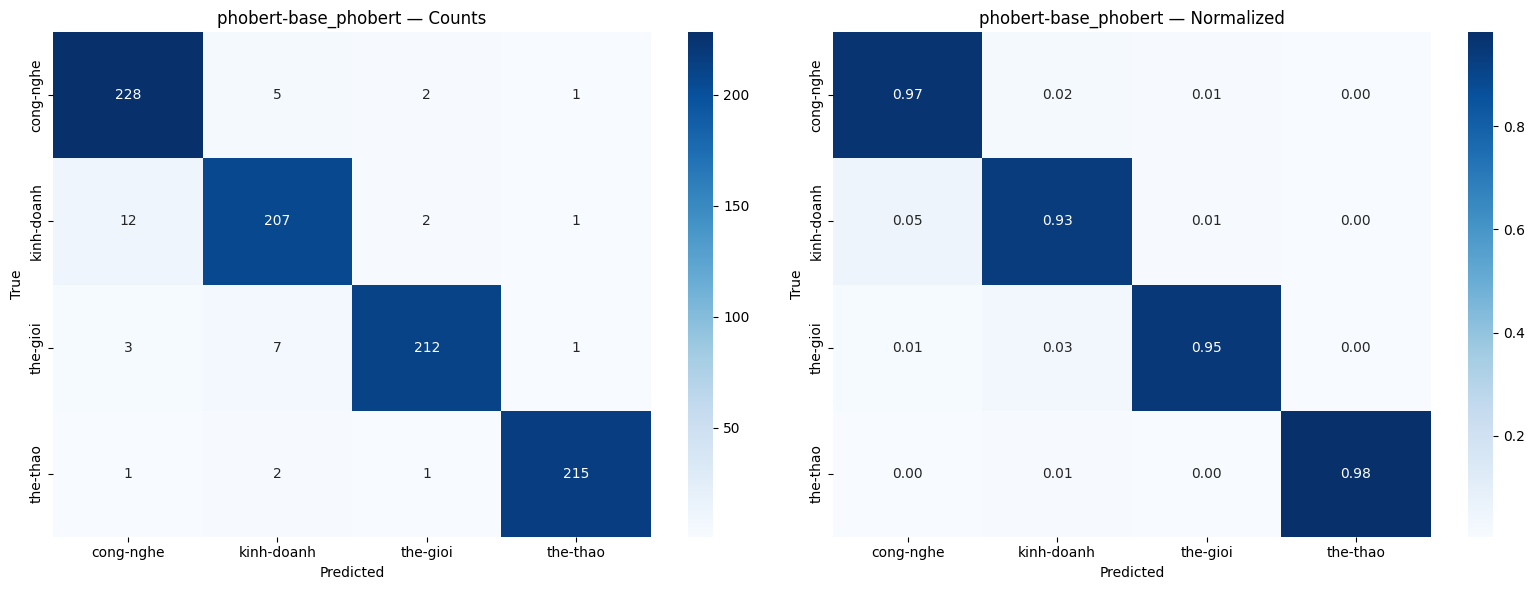

Model saved → ./saved_models/phobert-base_phobert_best

NEW BEST: phobert-base_phobert
  F1: 0.9578  |  Accuracy: 0.9578  |  Precision: 0.9586  |  Recall: 0.9577
  Params: 135.20M total / 135.20M trainable


  OK phobert-base | basic
    F1(w)=0.9578  F1(mac)=0.9580  Acc=0.9578  Prec=0.9586  Rec=0.9577

────────────────────────────────────────────────────────────
  STRATEGY: SLIDING_WINDOW
────────────────────────────────────────────────────────────

TRAINING: phobert-base_sliding_window
  Strategy: Sliding Window | window=128 | stride=64 (50%) | MAX pool
  Building datasets ...
  Params: 135.20M total / 135.20M trainable


  Train:   0%|          | 0/1084 [00:00<?, ?it/s]

  Eval :   0%|          | 0/96 [00:00<?, ?it/s]

  Epoch 1/3 | Loss=0.3388 Acc=0.8870 | Val Loss=0.1672 F1=0.9502 F1_mac=0.9501 Acc=0.9503 Prec=0.9504 Rec=0.9503
  [+] New best val F1: 0.9502


  Train:   0%|          | 0/1084 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/1084 [00:00<?, ?it/s]

  Eval :   0%|          | 0/96 [00:00<?, ?it/s]

  Epoch 3/3 | Loss=0.0602 Acc=0.9841 | Val Loss=0.1823 F1=0.9593 F1_mac=0.9592 Acc=0.9595 Prec=0.9601 Rec=0.9595
  [+] New best val F1: 0.9593


  Eval :   0%|          | 0/113 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
TEST RESULTS: phobert-base_sliding_window
  F1 (weighted): 0.9611
  F1 (macro)   : 0.9613
  Accuracy     : 0.9611
  Precision    : 0.9612
  Recall       : 0.9611
───────────────────────────────────────────────────────


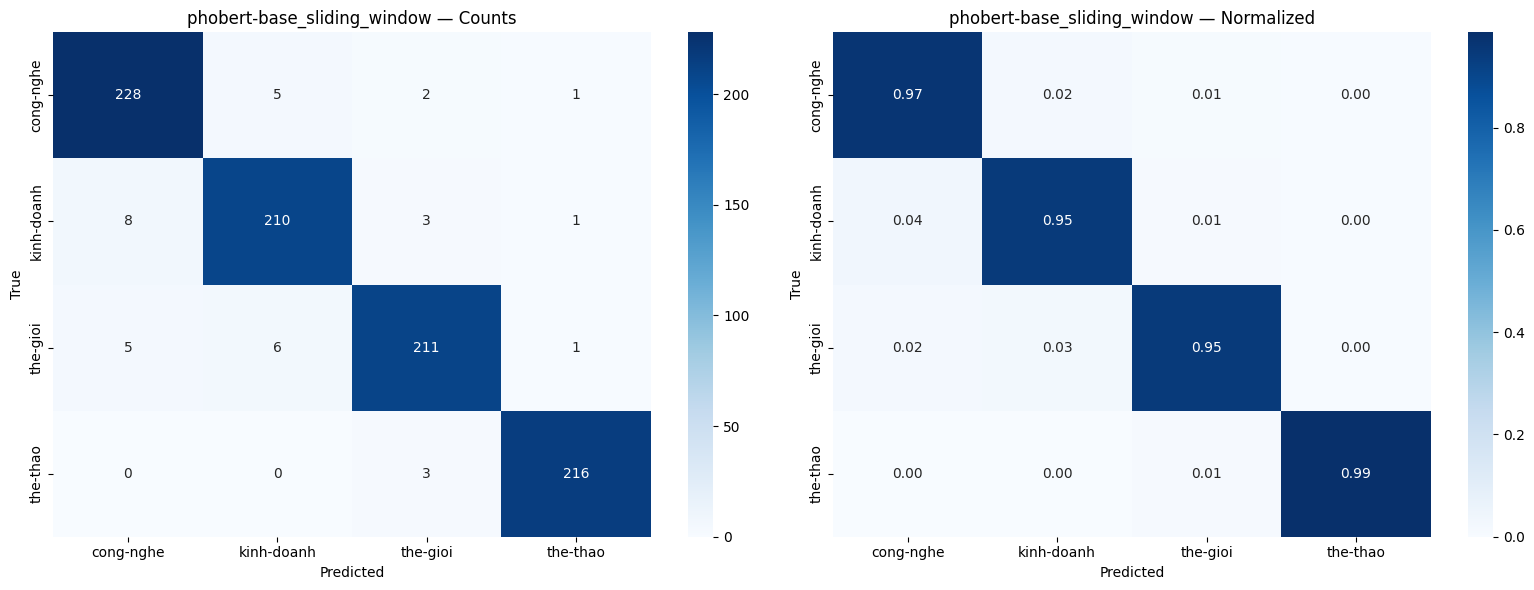


NEW BEST: phobert-base_sliding_window
  F1: 0.9611  |  Accuracy: 0.9611  |  Precision: 0.9612  |  Recall: 0.9611
  Params: 135.20M total / 135.20M trainable


  OK phobert-base | sliding_window
    F1(w)=0.9611  F1(mac)=0.9613  Acc=0.9611  Prec=0.9612  Rec=0.9611

────────────────────────────────────────────────────────────
  STRATEGY: HIERARCHICAL
────────────────────────────────────────────────────────────

TRAINING: phobert-base_hierarchical
  Strategy: Hierarchical | chunk=64 | stride=32 (50%) | Bi-LSTM(256)
  Building datasets ...
  Params: 137.30M total / 137.30M trainable


  Train:   0%|          | 0/1084 [00:00<?, ?it/s]

  Eval :   0%|          | 0/96 [00:00<?, ?it/s]

  Epoch 1/3 | Loss=0.4127 Acc=0.8886 | Val Loss=0.1937 F1=0.9621 F1_mac=0.9620 Acc=0.9621 Prec=0.9626 Rec=0.9621
  [+] New best val F1: 0.9621


  Train:   0%|          | 0/1084 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/1084 [00:00<?, ?it/s]

  Eval :   0%|          | 0/96 [00:00<?, ?it/s]

  Epoch 3/3 | Loss=0.0904 Acc=0.9804 | Val Loss=0.2040 F1=0.9635 F1_mac=0.9634 Acc=0.9634 Prec=0.9639 Rec=0.9634


  Eval :   0%|          | 0/113 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
TEST RESULTS: phobert-base_hierarchical
  F1 (weighted): 0.9566
  F1 (macro)   : 0.9569
  Accuracy     : 0.9567
  Precision    : 0.9568
  Recall       : 0.9567
───────────────────────────────────────────────────────


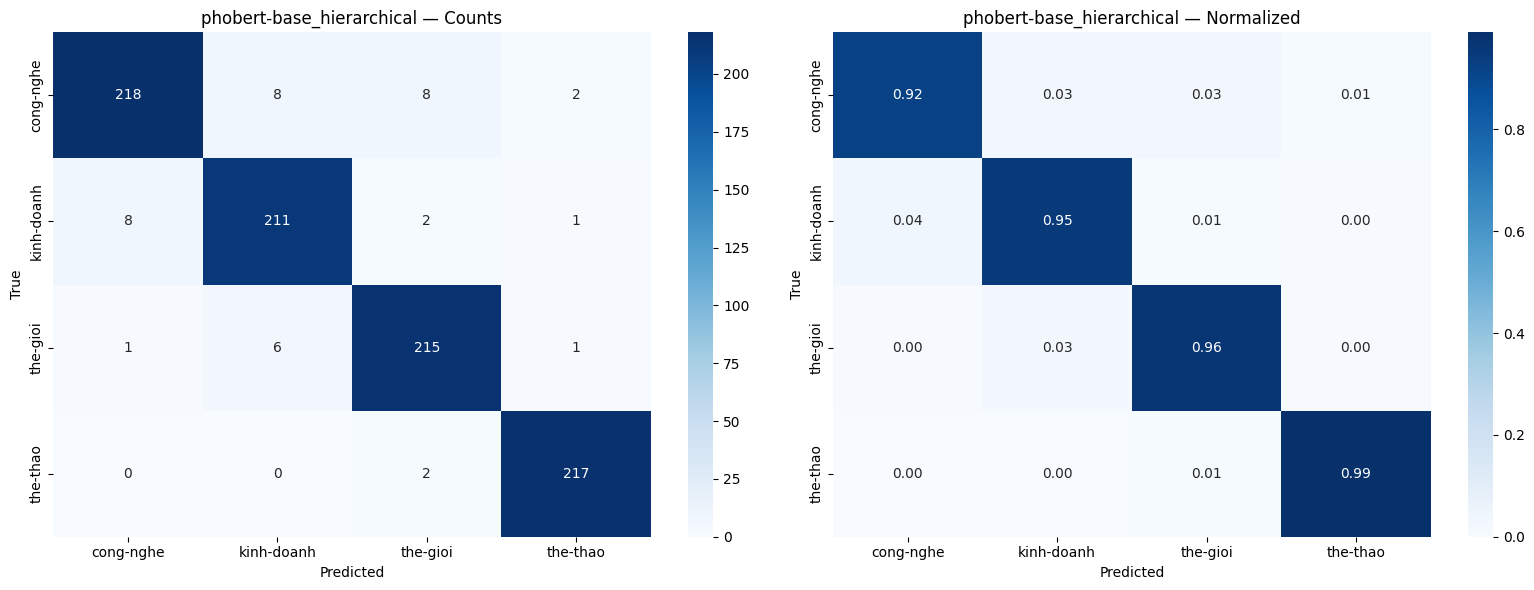


  OK phobert-base | hierarchical
    F1(w)=0.9566  F1(mac)=0.9569  Acc=0.9567  Prec=0.9568  Rec=0.9567

######################################################################
# MODEL: phobert-large
######################################################################

────────────────────────────────────────────────────────────
  STRATEGY: BASIC
────────────────────────────────────────────────────────────

TRAINING: phobert-large_phobert
  Size   : large (24 layers, 370M)
  LR     : 1e-05
  Batch  : 4 (grad_acc=16)


Map:   0%|          | 0/4335 [00:00<?, ? examples/s]

Map:   0%|          | 0/765 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]


[PARAMS]
  Total     : 369,429,508 (369.43M)
  Trainable : 369,429,508 (369.43M)
  Hidden    : 1024  |  Layers: 24

Training ...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,Precision,Recall
1,No log,0.177190,0.958170,0.958160,0.958100,0.958172,0.958094
2,0.624100,0.132435,0.960784,0.960825,0.960750,0.960847,0.960725
3,0.104200,0.124296,0.967320,0.967340,0.967264,0.967611,0.967256



Evaluating on test set ...



──────────────────────────────────────────────────
TEST RESULTS: phobert-large_phobert
  F1 (weighted) : 0.9634
  F1 (macro)    : 0.9635
  Accuracy      : 0.9633
  Precision     : 0.9638
  Recall        : 0.9634
──────────────────────────────────────────────────


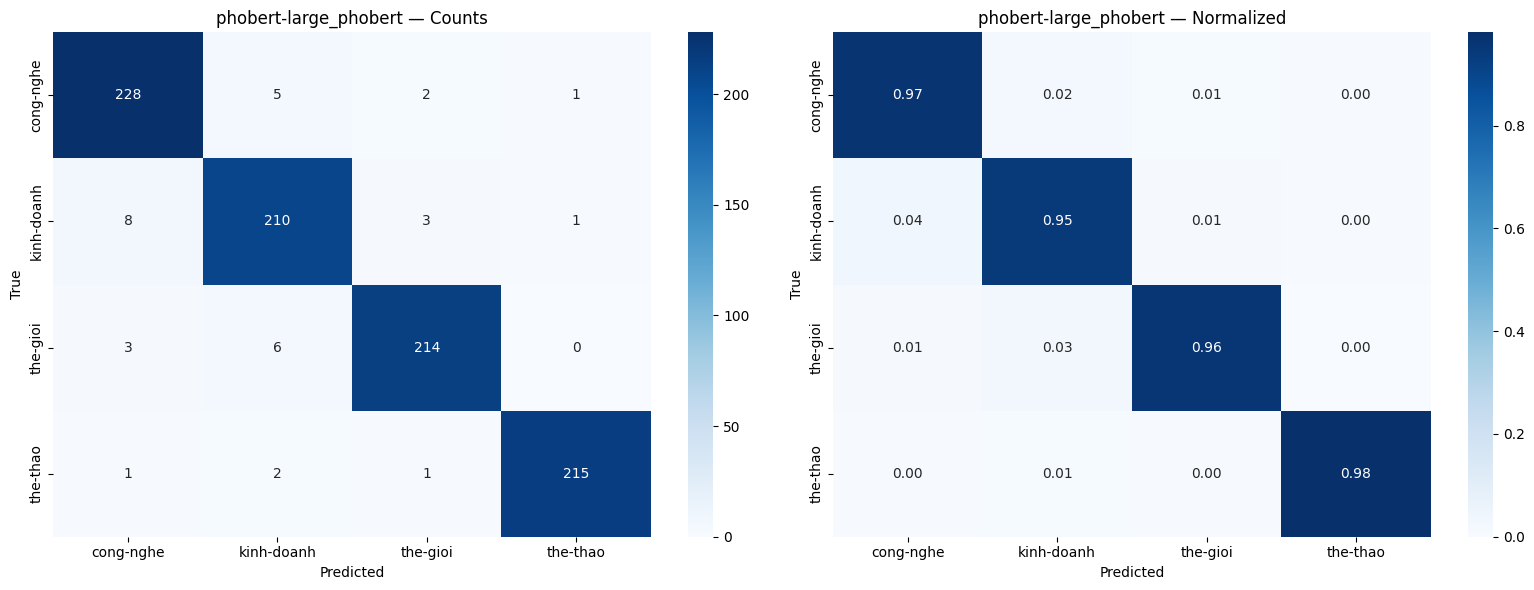

Model saved → ./saved_models/phobert-large_phobert_best

NEW BEST: phobert-large_phobert
  F1: 0.9634  |  Accuracy: 0.9633  |  Precision: 0.9638  |  Recall: 0.9634
  Params: 369.43M total / 369.43M trainable


  OK phobert-large | basic
    F1(w)=0.9634  F1(mac)=0.9635  Acc=0.9633  Prec=0.9638  Rec=0.9634

────────────────────────────────────────────────────────────
  STRATEGY: SLIDING_WINDOW
────────────────────────────────────────────────────────────

TRAINING: phobert-large_sliding_window
  Strategy: Sliding Window | window=128 | stride=64 (50%) | MAX pool
  Building datasets ...
  Params: 369.43M total / 369.43M trainable


  Train:   0%|          | 0/2168 [00:00<?, ?it/s]

  Eval :   0%|          | 0/192 [00:00<?, ?it/s]

  Epoch 1/3 | Loss=0.3709 Acc=0.8588 | Val Loss=0.1695 F1=0.9568 F1_mac=0.9567 Acc=0.9569 Prec=0.9570 Rec=0.9569
  [+] New best val F1: 0.9568


  Train:   0%|          | 0/2168 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/2168 [00:00<?, ?it/s]

  Eval :   0%|          | 0/192 [00:00<?, ?it/s]

  Epoch 3/3 | Loss=0.0555 Acc=0.9852 | Val Loss=0.1974 F1=0.9646 F1_mac=0.9646 Acc=0.9647 Prec=0.9646 Rec=0.9647
  [+] New best val F1: 0.9646


  Eval :   0%|          | 0/225 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
TEST RESULTS: phobert-large_sliding_window
  F1 (weighted): 0.9633
  F1 (macro)   : 0.9636
  Accuracy     : 0.9633
  Precision    : 0.9636
  Recall       : 0.9633
───────────────────────────────────────────────────────


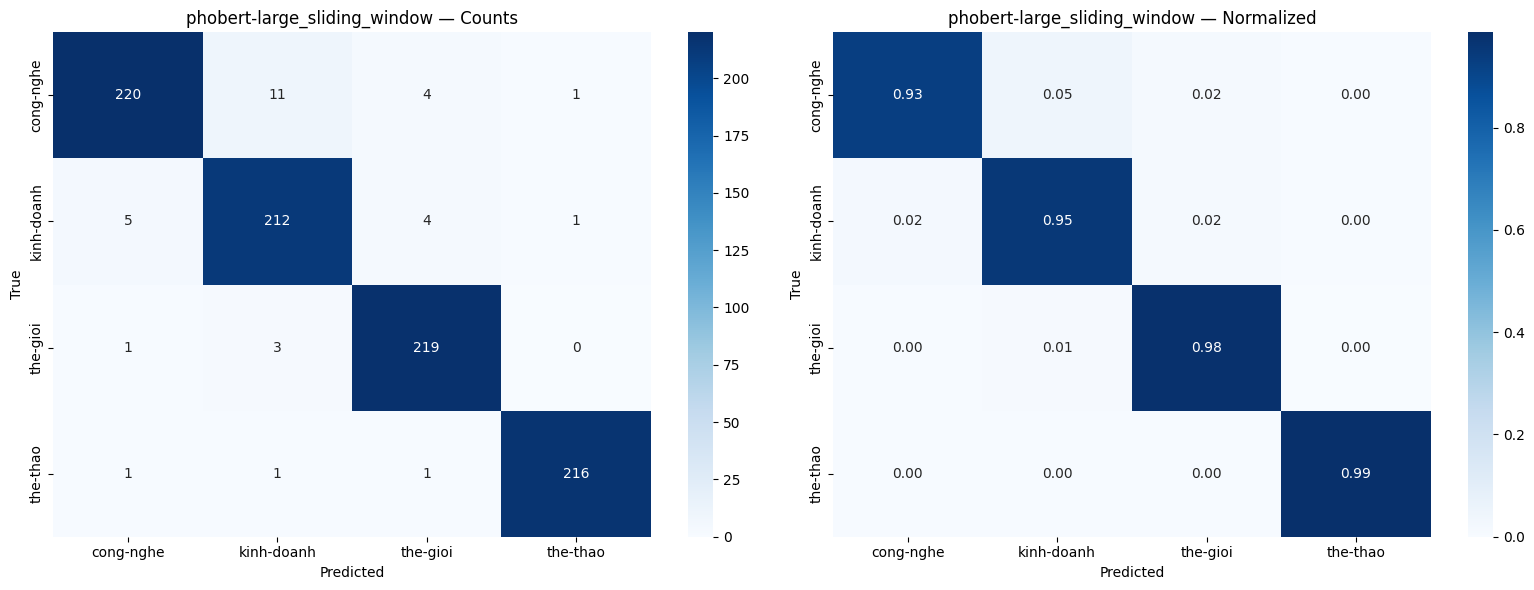


  OK phobert-large | sliding_window
    F1(w)=0.9633  F1(mac)=0.9636  Acc=0.9633  Prec=0.9636  Rec=0.9633

────────────────────────────────────────────────────────────
  STRATEGY: HIERARCHICAL
────────────────────────────────────────────────────────────

TRAINING: phobert-large_hierarchical
  Strategy: Hierarchical | chunk=64 | stride=32 (50%) | Bi-LSTM(256)
  Building datasets ...
  Params: 372.05M total / 372.05M trainable


  Train:   0%|          | 0/2168 [00:00<?, ?it/s]

  Eval :   0%|          | 0/192 [00:00<?, ?it/s]

  Epoch 1/3 | Loss=0.4284 Acc=0.8584 | Val Loss=0.3225 F1=0.9344 F1_mac=0.9343 Acc=0.9346 Prec=0.9386 Rec=0.9346
  [+] New best val F1: 0.9344


  Train:   0%|          | 0/2168 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/2168 [00:00<?, ?it/s]

  Eval :   0%|          | 0/192 [00:00<?, ?it/s]

  Epoch 3/3 | Loss=0.1099 Acc=0.9781 | Val Loss=0.1962 F1=0.9634 F1_mac=0.9633 Acc=0.9634 Prec=0.9635 Rec=0.9634
  [+] New best val F1: 0.9634


  Eval :   0%|          | 0/225 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
TEST RESULTS: phobert-large_hierarchical
  F1 (weighted): 0.9578
  F1 (macro)   : 0.9579
  Accuracy     : 0.9578
  Precision    : 0.9579
  Recall       : 0.9578
───────────────────────────────────────────────────────


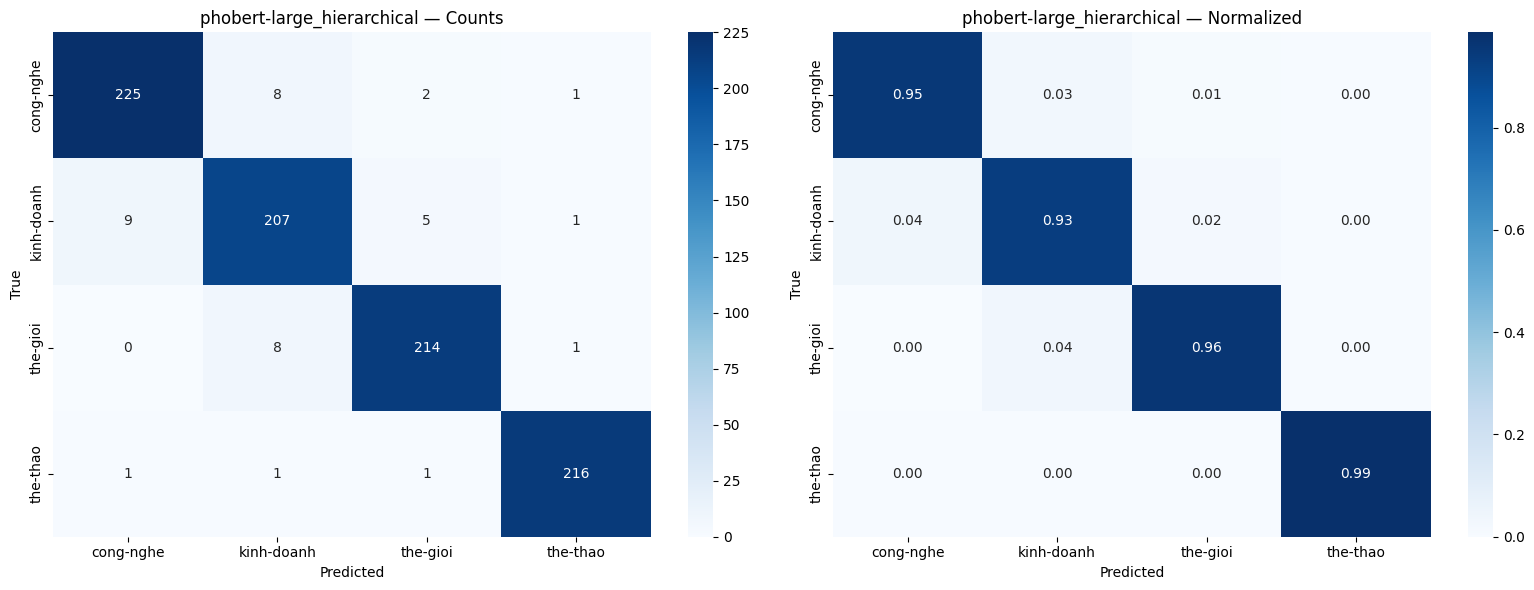


  OK phobert-large | hierarchical
    F1(w)=0.9578  F1(mac)=0.9579  Acc=0.9578  Prec=0.9579  Rec=0.9578


In [13]:
print("\n" + "="*70)
print(" STARTING FULL TRAINING PIPELINE")
print("="*70)
print(f" Models    : {list(MODELS_TO_TRAIN.keys())}")
print(f" Strategies: Basic | Sliding Window | Hierarchical")
print(f" Total runs: {len(MODELS_TO_TRAIN)} models x 3 strategies = "
      f"{len(MODELS_TO_TRAIN) * 3} configurations")
print("")
print(" [Basic]          : truncate 512 token, [CLS] pooler_output, HF Trainer")
print(f" [Sliding Window] : window={SW_CHUNK_SIZE+2}, stride={SW_CHUNK_STRIDE} (50%), MAX pool, max_chunks={SW_MAX_CHUNKS}")
print(f" [Hierarchical]   : chunk={HIER_CHUNK_SIZE}, stride={HIER_CHUNK_STRIDE} (50%), Bi-LSTM, max_chunks={HIER_MAX_CHUNKS}")
print("="*70)

STRATEGY_REGISTRY = {
    "basic":          train_phobert,
    "sliding_window": train_phobert_sliding_window,
    "hierarchical":   train_phobert_hierarchical,
}

for model_name, model_path in MODELS_TO_TRAIN.items():
    print(f"\n{'#'*70}")
    print(f"# MODEL: {model_name}")
    print(f"{'#'*70}")

    for strategy_name, train_fn in STRATEGY_REGISTRY.items():
        print(f"\n{'─'*60}")
        print(f"  STRATEGY: {strategy_name.upper()}")
        print(f"{'─'*60}")
        try:
            result = train_fn(model_name, model_path, num_classes)
            f1       = result.get("eval_f1",       result.get("f1",        0))
            f1_macro = result.get("eval_f1_macro",  result.get("f1_macro",  0))
            acc      = result.get("eval_accuracy",  result.get("accuracy",  0))
            p        = result.get("eval_precision", result.get("precision", 0))
            r        = result.get("eval_recall",    result.get("recall",    0))
            print(f"\n  OK {model_name} | {strategy_name}")
            print(f"    F1(w)={f1:.4f}  F1(mac)={f1_macro:.4f}  Acc={acc:.4f}  Prec={p:.4f}  Rec={r:.4f}")

        except torch.cuda.OutOfMemoryError:
            print(f"\n  [OOM] {model_name} | {strategy_name} -- het VRAM, bo qua.")
            gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()

        except Exception as e:
            print(f"\n  [ERR] {model_name} | {strategy_name}: {e}")
            import traceback; traceback.print_exc()

        finally:
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()


 ALL TRAINING COMPLETE!

  FINAL SUMMARY
                          Model      F1  Accuracy  Precision  Recall   Params
1         phobert-large_phobert  0.9634    0.9633     0.9638  0.9634  369.43M
2  phobert-large_sliding_window  0.9633    0.9633     0.9636  0.9633  369.43M
3   phobert-base_sliding_window  0.9611    0.9611     0.9612  0.9611  135.20M
4          phobert-base_phobert  0.9578    0.9578     0.9586  0.9577  135.20M
5    phobert-large_hierarchical  0.9578    0.9578     0.9579  0.9578  372.05M
6     phobert-base_hierarchical  0.9566    0.9567     0.9568  0.9567  137.30M

Saved: ./model_comparison_summary.csv

  BEST: phobert-large_phobert
  F1=0.9634  Acc=0.9633  Precision=0.9638  Recall=0.9634
  Params: 369.43M


FINAL BEST MODEL → ./saved_models/FINAL_BEST


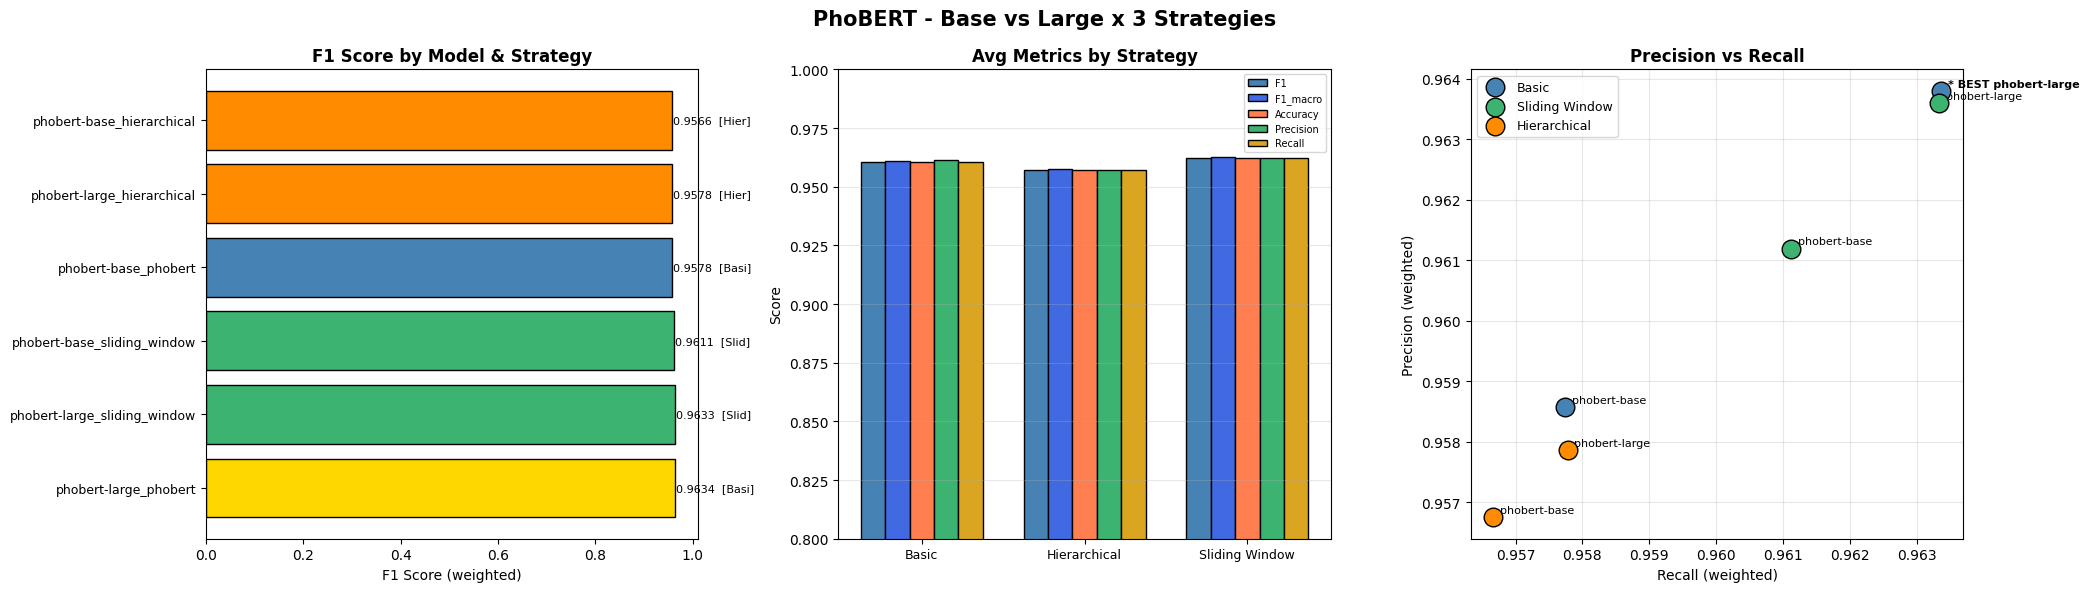

Saved: ./FINAL_results_all_strategies.png

  BANG TONG KET TAT CA CAC CAU HINH
                       Model       Strategy Accuracy Precision Recall     F1 F1_macro Params(M)
       phobert-large_phobert          Basic   0.9633    0.9638 0.9634 0.9634   0.9635    369.4M
phobert-large_sliding_window Sliding Window   0.9633    0.9636 0.9633 0.9633   0.9636    369.4M
 phobert-base_sliding_window Sliding Window   0.9611    0.9612 0.9611 0.9611   0.9613    135.2M
        phobert-base_phobert          Basic   0.9578    0.9586 0.9577 0.9578   0.9580    135.2M
  phobert-large_hierarchical   Hierarchical   0.9578    0.9579 0.9578 0.9578   0.9579    372.1M
   phobert-base_hierarchical   Hierarchical   0.9567    0.9568 0.9567 0.9566   0.9569    137.3M

Tong so cau hinh: 6
Saved: ./model_comparison_summary.csv

 PIPELINE COMPLETE
   ./saved_models/FINAL_BEST/BEST_MODEL_INFO.json
   ./saved_models/FINAL_BEST/model.pt


In [14]:
print("\n" + "="*70)
print(" ALL TRAINING COMPLETE!")
print("="*70)

print_final_summary()
final_best_dir = save_best_model_final()

if len(GLOBAL_RESULTS["all_results"]) > 0:
    def _get_strategy(name):
        if "sliding" in name: return "Sliding Window"
        if "hier"    in name: return "Hierarchical"
        return "Basic"

    # FIX 4: thêm F1_macro vào plot_data
    plot_data = pd.DataFrame([
        {
            "Model":     r["config_name"],
            "Strategy":  _get_strategy(r["config_name"]),
            "Accuracy":  r["test_accuracy"],
            "Precision": r["test_precision"],
            "Recall":    r["test_recall"],
            "F1":        r["test_f1"],
            "F1_macro":  r.get("test_f1_macro", 0),
            "Params(M)": r.get("total_params", 0) / 1_000_000,
        }
        for r in GLOBAL_RESULTS["all_results"]
    ]).sort_values("F1", ascending=False).reset_index(drop=True)

    best_f1 = plot_data["F1"].max()
    strategy_colors = {
        "Basic":          "steelblue",
        "Sliding Window": "mediumseagreen",
        "Hierarchical":   "darkorange",
    }

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.suptitle("PhoBERT - Base vs Large x 3 Strategies",
                 fontsize=15, fontweight="bold")

    # Plot 1: F1 (weighted) bar
    y_pos  = range(len(plot_data))
    colors = [("gold" if v == best_f1 else strategy_colors.get(s, "gray"))
              for v, s in zip(plot_data["F1"], plot_data["Strategy"])]
    axes[0].barh(y_pos, plot_data["F1"], color=colors, edgecolor="black")
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(plot_data["Model"], fontsize=9)
    axes[0].set_xlabel("F1 Score (weighted)")
    axes[0].set_title("F1 Score by Model & Strategy", fontweight="bold")
    for i, (v, s) in enumerate(zip(plot_data["F1"], plot_data["Strategy"])):
        axes[0].text(v + 0.002, i, f"{v:.4f}  [{s[:4]}]", va="center", fontsize=8)

    # Plot 2: Strategy avg — tất cả 5 metrics
    strat_avg = plot_data.groupby("Strategy")[
        ["F1","F1_macro","Accuracy","Precision","Recall"]
    ].mean()
    x, width = range(len(strat_avg)), 0.15
    metric_styles = [
        ("F1",        "steelblue"),
        ("F1_macro",  "royalblue"),
        ("Accuracy",  "coral"),
        ("Precision", "mediumseagreen"),
        ("Recall",    "goldenrod"),
    ]
    for i, (col, color) in enumerate(metric_styles):
        axes[1].bar([xi + i*width for xi in x], strat_avg[col],
                    width=width, label=col, color=color, edgecolor="black")
    axes[1].set_xticks([xi + 2*width for xi in x])
    axes[1].set_xticklabels(strat_avg.index, fontsize=9)
    axes[1].set_ylabel("Score")
    axes[1].set_title("Avg Metrics by Strategy", fontweight="bold")
    axes[1].legend(fontsize=7)
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].set_ylim(0.8, 1.0)

    # Plot 3: Precision vs Recall scatter
    for strat, color in strategy_colors.items():
        sub = plot_data[plot_data["Strategy"] == strat]
        axes[2].scatter(sub["Recall"], sub["Precision"], s=180,
                        color=color, edgecolors="black", label=strat, zorder=4)
        for _, row in sub.iterrows():
            lbl     = row["Model"].split("_")[0]
            is_best = (row["F1"] == best_f1)
            axes[2].annotate(
                ("* BEST " if is_best else "") + lbl,
                xy=(row["Recall"], row["Precision"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=8, fontweight="bold" if is_best else "normal"
            )
    axes[2].set_xlabel("Recall (weighted)")
    axes[2].set_ylabel("Precision (weighted)")
    axes[2].set_title("Precision vs Recall", fontweight="bold")
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("./FINAL_results_all_strategies.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ./FINAL_results_all_strategies.png")

    # FIX 4: bảng tổng kết đầy đủ 5 metrics
    print("\n" + "="*110)
    print("  BANG TONG KET TAT CA CAC CAU HINH")
    print("="*110)
    summary = plot_data[[
        "Model","Strategy","Accuracy","Precision","Recall","F1","F1_macro","Params(M)"
    ]].copy()
    for col in ["Accuracy","Precision","Recall","F1","F1_macro"]:
        summary[col] = summary[col].map(lambda v: f"{v:.4f}")
    summary["Params(M)"] = summary["Params(M)"].map(lambda v: f"{v:.1f}M")
    print(summary.to_string(index=False))
    summary.to_csv("./model_comparison_summary.csv", index=False)
    print(f"\nTong so cau hinh: {len(summary)}")
    print("Saved: ./model_comparison_summary.csv")

print("\n" + "="*70)
print(" PIPELINE COMPLETE")
print("="*70)
if final_best_dir:
    print(f"   {final_best_dir}/BEST_MODEL_INFO.json")
    print(f"   {final_best_dir}/model.pt")
print("="*70)


 TRAINING CURVES — per model & strategy


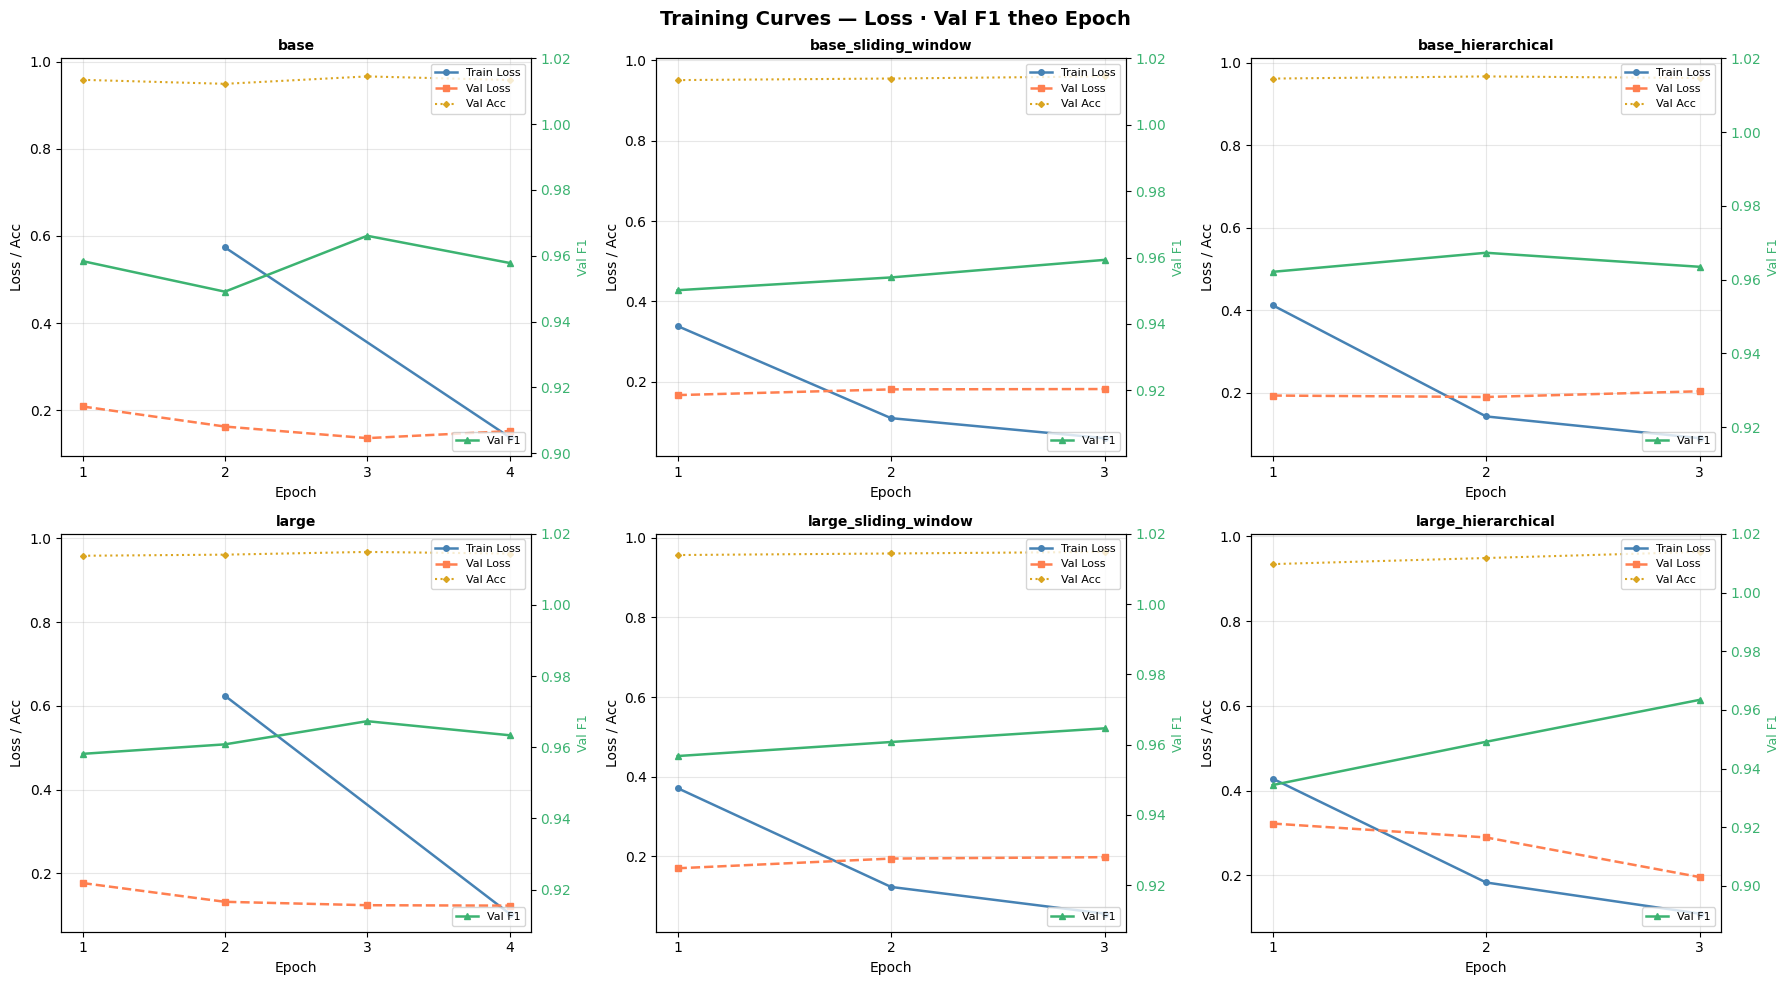

Saved: ./training_curves.png


In [15]:
print("\n" + "="*70)
print(" TRAINING CURVES — per model & strategy")
print("="*70)

if not TRAINING_HISTORIES:
    print("Chưa có dữ liệu history. Chạy training trước.")
else:
    configs   = list(TRAINING_HISTORIES.keys())
    n         = len(configs)
    ncols     = 3
    nrows     = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes      = np.array(axes).reshape(-1) if n > 1 else [axes]
    fig.suptitle("Training Curves — Loss · Val F1 theo Epoch",
                 fontsize=14, fontweight="bold")

    for ax, config_name in zip(axes, configs):
        hist = TRAINING_HISTORIES[config_name]

        # Epochs
        n_val = len(hist.get("val_f1", hist.get("val_loss", [])))
        x_val = list(range(1, n_val + 1))

        # Train loss (có thể nhiều steps hơn epochs với HF Trainer)
        tr_loss = hist.get("train_loss", [])
        if tr_loss:
            n_tr = len(tr_loss)
            x_tr = [i * n_val / n_tr for i in range(1, n_tr + 1)] if n_tr != n_val else x_val
            ax.plot(x_tr, tr_loss, "o-", color="steelblue", linewidth=1.8,
                    markersize=4, label="Train Loss")

        # Val loss
        vl_loss = hist.get("val_loss", [])
        if vl_loss:
            ax.plot(x_val[:len(vl_loss)], vl_loss, "s--", color="coral",
                    linewidth=1.8, markersize=4, label="Val Loss")

        # Val F1 — trục phụ
        vl_f1 = hist.get("val_f1", [])
        if vl_f1:
            ax2 = ax.twinx()
            ax2.plot(x_val[:len(vl_f1)], vl_f1, "^-", color="mediumseagreen",
                     linewidth=1.8, markersize=4, label="Val F1")
            ax2.set_ylim(max(0, min(vl_f1) - 0.05), 1.02)
            ax2.set_ylabel("Val F1", color="mediumseagreen", fontsize=9)
            ax2.tick_params(axis="y", labelcolor="mediumseagreen")
            ax2.legend(loc="lower right", fontsize=8)

        # Val Acc
        vl_acc = hist.get("val_acc", [])
        if vl_acc:
            ax.plot(x_val[:len(vl_acc)], vl_acc, "D:", color="goldenrod",
                    linewidth=1.5, markersize=3, label="Val Acc")

        short = config_name.replace("phobert-","").replace("_phobert","")
        ax.set_title(short, fontsize=10, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss / Acc")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xticks(x_val)

    # Ẩn axes thừa
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig("./training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ./training_curves.png")

In [16]:
print("\n" + "="*70)
print(" PHÂN TÍCH MẪU PHÂN LOẠI SAI")
print("="*70)

classes = list(label_encoder.classes_)

for r in GLOBAL_RESULTS["all_results"]:
    cfg    = r["config_name"]
    preds  = r.get("test_preds",  [])
    labels = r.get("test_labels", [])
    texts  = r.get("test_texts",  [])

    if not preds or not labels:
        print(f"\n[SKIP] {cfg} — không có dữ liệu preds/labels")
        continue

    preds  = np.array(preds)
    labels = np.array(labels)
    wrong_idx = np.where(preds != labels)[0]

    print(f"\n{'─'*70}")
    print(f"Model: {cfg}")
    print(f"  Tổng test: {len(labels)} | Sai: {len(wrong_idx)} "
          f"({len(wrong_idx)/len(labels)*100:.1f}%)")

    # ── Thống kê sai theo class ───────────────────────────────────────────────
    from collections import Counter
    err_true  = Counter(labels[wrong_idx])
    err_pred  = Counter(preds[wrong_idx])
    print("  Sai nhiều nhất theo nhãn thật:")
    for cls_id, cnt in err_true.most_common():
        print(f"    [{classes[cls_id]}] → sai {cnt} lần")

    # ── Hiển thị 5 mẫu sai điển hình ────────────────────────────────────────
    print(f"\n  5 mẫu phân loại sai điển hình:")
    print(f"  {'#':>3}  {'Nhãn thật':<18}  {'Dự đoán':<18}  Nội dung (80 ký tự đầu)")
    print(f"  {'─'*3}  {'─'*18}  {'─'*18}  {'─'*40}")
    for rank, idx in enumerate(wrong_idx[:5], 1):
        true_lbl = classes[labels[idx]]
        pred_lbl = classes[preds[idx]]
        snippet  = str(texts[idx])[:80].replace("\n", " ") if texts else "(no text)"
        print(f"  {rank:>3}  {true_lbl:<18}  {pred_lbl:<18}  {snippet}")

    # ── Ma trận nhầm lẫn dạng text cho các class sai nhiều nhất ──────────────
    print(f"\n  Ma trận nhầm lẫn (true → pred) — top 10 cặp sai:")
    pairs = Counter(zip(labels[wrong_idx], preds[wrong_idx]))
    print(f"  {'True':<20}  {'Predicted':<20}  Count")
    print(f"  {'─'*20}  {'─'*20}  {'─'*5}")
    for (t, p_), cnt in pairs.most_common(10):
        print(f"  {classes[t]:<20}  {classes[p_]:<20}  {cnt}")

print("\n" + "="*70)
print(" ANALYSIS COMPLETE")
print("="*70)


 PHÂN TÍCH MẪU PHÂN LOẠI SAI

──────────────────────────────────────────────────────────────────────
Model: phobert-base_phobert
  Tổng test: 900 | Sai: 38 (4.2%)
  Sai nhiều nhất theo nhãn thật:
    [kinh-doanh] → sai 15 lần
    [the-gioi] → sai 11 lần
    [cong-nghe] → sai 8 lần
    [the-thao] → sai 4 lần

  5 mẫu phân loại sai điển hình:
    #  Nhãn thật           Dự đoán             Nội dung (80 ký tự đầu)
  ───  ──────────────────  ──────────────────  ────────────────────────────────────────
    1  cong-nghe           kinh-doanh          Xanh hóa công nghệ - hướng đi tất yếu của doanh nghiệp Việt  Doanh nghiệp chủ độ
    2  kinh-doanh          cong-nghe           Những yếu tố mới tạo nền tảng cho mục tiêu tăng trưởng hai con số  Đặt khu vực k
    3  the-gioi            kinh-doanh          Giá vàng tăng liên tiếp, ngân hàng ở Trung Quốc đồng loạt phát cảnh báo rủi ro  
    4  kinh-doanh          cong-nghe           Ví điện tử song hành ngân hàng: Thị trường thanh toán số trưởng th

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()